## Import Libraries

In [ ]:
# import torch
# print(torch.__version__)
# print("CUDA Available:", torch.cuda.is_available())
# print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

2.5.1+cu121
CUDA Available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import Trainer, TrainingArguments
from datasets import Dataset

d:\Project Infy\jira_gpu_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

Using device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


## Loading Dataset

In [4]:
df = pd.read_csv(r"D:\Project Infy\jira_issues_with_workload.csv")

print("Dataset shape: ", df.shape)
df.head()

Dataset shape:  (100000, 15)


,issue_key,summary,description,issue_type,priority,status,created,updated,projectname,commentcount,attachmentcount,votes,watch_count,labels,total_time_spent_seconds
0,AAR-6171,The Subject matter Of Biorhythms Set,!https://upload.wikimedia.org/wikipedia/common...,Bug,Major,Open,2021-07-23 14:25:25,2021-07-23 14:25:25,AAR,Unknown,0.0,0,1,NaN,0.0
1,AAR-6170,Buy Oxycontin No Prescription Needed | Buy Oxy...,h2. *What is Oxycontin?*\r\n\r\n[Oxycontin |ht...,New Feature,Major,Open,2021-07-23 10:53:39,2021-07-23 10:53:39,AAR,Unknown,1.0,0,1,buyoxycontin,0.0
2,AAR-6169,Natural Remedies For Poor Erection,!https://www.dropshipherbalsupplements.com/wp-...,Bug,Major,Open,2021-07-23 10:28:27,2021-07-23 10:28:27,AAR,Unknown,0.0,0,1,NaN,0.0
3,AAR-6168,download joker,h1. [JOKER GAMING|http://download-jokergaming....,Bug,Major,Open,2021-07-23 09:56:45,2021-07-23 09:56:45,AAR,Unknown,0.0,0,1,NaN,0.0
4,AAR-6167,BONANZA88 Slot Online Terbaik Indonesia,Kami adalah [slot online|https://172.104.61.28...,Bug,Major,Open,2021-07-23 08:05:06,2021-07-23 08:05:06,AAR,Unknown,0.0,0,1,NaN,0.0


### Dataset Info

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   issue_key                 100000 non-null  str    
 1   summary                   100000 non-null  str    
 2   description               100000 non-null  str    
 3   issue_type                100000 non-null  str    
 4   priority                  100000 non-null  str    
 5   status                    100000 non-null  str    
 6   created                   100000 non-null  str    
 7   updated                   100000 non-null  str    
 8   projectname               100000 non-null  str    
 9   commentcount              100000 non-null  str    
 10  attachmentcount           100000 non-null  float64
 11  votes                     100000 non-null  int64  
 12  watch_count               100000 non-null  int64  
 13  labels                    18469 non-null   str    
 14  

## Missing Values Check

In [6]:
(df.isnull().sum() / len(df)) * 100

issue_key                    0.000
summary                      0.000
description                  0.000
issue_type                   0.000
priority                     0.000
status                       0.000
created                      0.000
updated                      0.000
projectname                  0.000
commentcount                 0.000
attachmentcount              0.000
votes                        0.000
watch_count                  0.000
labels                      81.531
total_time_spent_seconds     0.000
dtype: float64

### Data Cleaning

In [7]:
df.replace("Unknown", np.nan, inplace=True)

df.dropna(subset=["summary", "description", "issue_type", "priority"], inplace=True)

df["text"] = df["summary"].astype(str) + " " + df["description"].astype(str)

print("After cleaning shape:", df.shape)
df.head()

After cleaning shape: (86502, 16)


,issue_key,summary,description,issue_type,priority,status,created,updated,projectname,commentcount,attachmentcount,votes,watch_count,labels,total_time_spent_seconds,text
0,AAR-6171,The Subject matter Of Biorhythms Set,!https://upload.wikimedia.org/wikipedia/common...,Bug,Major,Open,2021-07-23 14:25:25,2021-07-23 14:25:25,AAR,NaN,0.0,0,1,NaN,0.0,The Subject matter Of Biorhythms Set !https://...
1,AAR-6170,Buy Oxycontin No Prescription Needed | Buy Oxy...,h2. *What is Oxycontin?*\r\n\r\n[Oxycontin |ht...,New Feature,Major,Open,2021-07-23 10:53:39,2021-07-23 10:53:39,AAR,NaN,1.0,0,1,buyoxycontin,0.0,Buy Oxycontin No Prescription Needed | Buy Oxy...
2,AAR-6169,Natural Remedies For Poor Erection,!https://www.dropshipherbalsupplements.com/wp-...,Bug,Major,Open,2021-07-23 10:28:27,2021-07-23 10:28:27,AAR,NaN,0.0,0,1,NaN,0.0,Natural Remedies For Poor Erection !https://ww...
3,AAR-6168,download joker,h1. [JOKER GAMING|http://download-jokergaming....,Bug,Major,Open,2021-07-23 09:56:45,2021-07-23 09:56:45,AAR,NaN,0.0,0,1,NaN,0.0,download joker h1. [JOKER GAMING|http://downlo...
4,AAR-6167,BONANZA88 Slot Online Terbaik Indonesia,Kami adalah [slot online|https://172.104.61.28...,Bug,Major,Open,2021-07-23 08:05:06,2021-07-23 08:05:06,AAR,NaN,0.0,0,1,NaN,0.0,BONANZA88 Slot Online Terbaik Indonesia Kami a...


### Verifying class distribution

In [8]:
print(df["issue_type"].value_counts())
print(df["priority"].value_counts())
print(df["status"].value_counts())

issue_type
Bug                   51404
Improvement           16535
Task                   8563
New Feature            4693
Sub-task               2612
Story                   861
Wish                    759
Test                    609
Epic                    182
Technical task           89
Documentation            84
Question                 51
Dependency upgrade       37
Brainstorming             7
Request                   4
Project                   4
IT Help                   3
New JIRA Project          2
TCK Challenge             2
New Git Repo              1
Name: count, dtype: int64
priority
Major       60988
Minor       12135
Critical     7584
Blocker      3621
Trivial      2160
Normal          6
Low             5
High            2
P4              1
Name: count, dtype: int64
status
Resolved           52736
Open               18216
Closed             14610
Patch Available      338
In Progress          284
Reopened             207
To Do                 77
Accepted              15

## Resolve Class Imbalance

### 1. Issue type problem

In [9]:
top_types = ["Bug", "Improvement", "Task", "New Feature", "Sub-task", "Story"]
df = df[df["issue_type"].isin(top_types)]

### 2. Priority problem

In [10]:
valid_priorities = ["Major", "Minor", "Critical", "Blocker", "Trivial"]
df = df[df["priority"].isin(valid_priorities)]

print("After filtering:", df.shape)

After filtering: (84657, 16)


## Text Cleaning Function

In [11]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"\n", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = text.translate(str.maketrans("", "", string.punctuation))
    return text

df["clean_text"] = df["text"].apply(clean_text)

df[["text", "clean_text"]].head()

,text,clean_text
0,The Subject matter Of Biorhythms Set !https://...,the subject matter of biorhythms set it doesn...
1,Buy Oxycontin No Prescription Needed | Buy Oxy...,buy oxycontin no prescription needed buy oxyc...
2,Natural Remedies For Poor Erection !https://ww...,natural remedies for poor erection with the s...
3,download joker h1. [JOKER GAMING|http://downlo...,download joker h1 joker gaming bermain judi sl...
4,BONANZA88 Slot Online Terbaik Indonesia Kami a...,bonanza88 slot online terbaik indonesia kami a...


## EDA Plots

### Issue Type Distribution

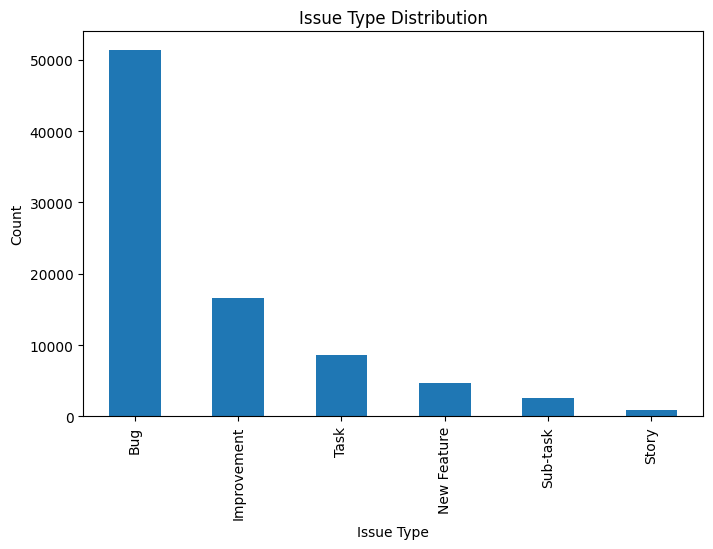

In [12]:
plt.figure(figsize=(8,5))
df["issue_type"].value_counts().plot(kind="bar")
plt.title("Issue Type Distribution")
plt.xlabel("Issue Type")
plt.ylabel("Count")
plt.show()

### Priority Distribution

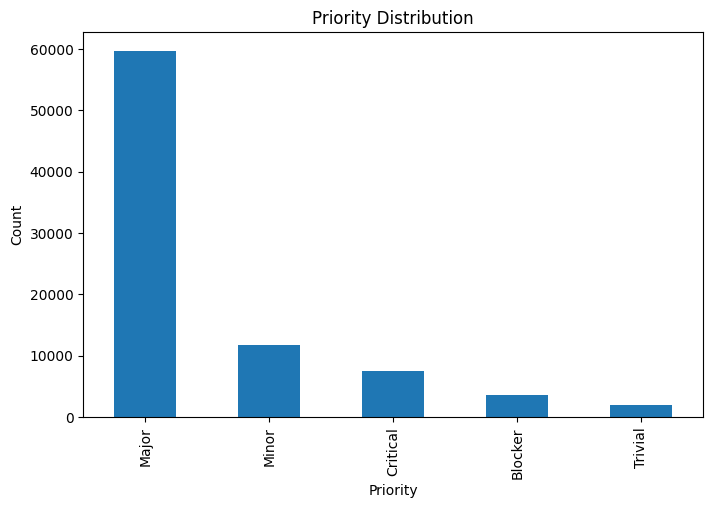

In [13]:
plt.figure(figsize=(8,5))
df["priority"].value_counts().plot(kind="bar")
plt.title("Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Count")
plt.show()

### Status Distribution

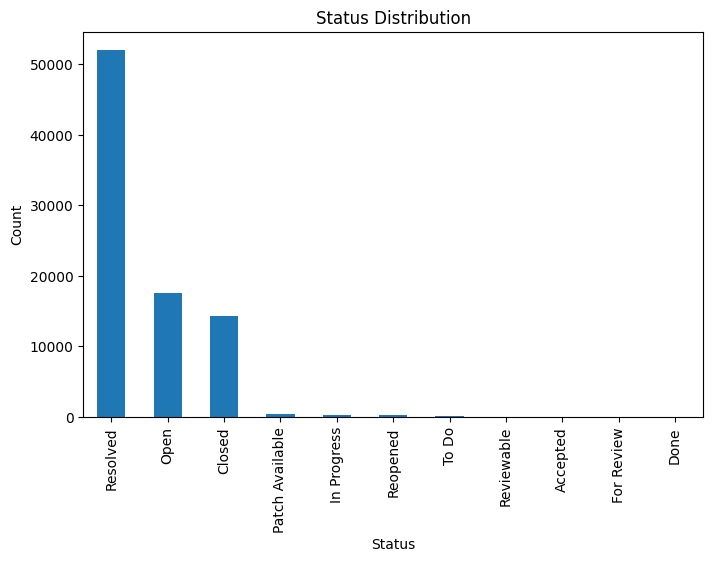

In [14]:
plt.figure(figsize=(8,5))
df["status"].value_counts().plot(kind="bar")
plt.title("Status Distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

## Issue Type Classification Using BERT

### Train Test Split

In [15]:
X = df["clean_text"]
y = df["issue_type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (67725,)
Test size: (16932,)


### Label Encoding

In [16]:
label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

num_labels = len(label_encoder.classes_)
print("Classes:", label_encoder.classes_)

Classes: ['Bug' 'Improvement' 'New Feature' 'Story' 'Sub-task' 'Task']


### Convert to HuggingFace Dataset

In [17]:
train_dataset = Dataset.from_dict({
    "text": X_train.tolist(),
    "label": y_train_enc.tolist()
})

test_dataset = Dataset.from_dict({
    "text": X_test.tolist(),
    "label": y_test_enc.tolist()
})

### Tokenization

In [18]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

Map: 100%|██████████| 16932/16932 [00:04<00:00, 4150.36 examples/s]


### Loading the model

In [19]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

model.to(device)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 10875.37it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


### Metric Function

In [20]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, preds)}

### Training Arguments

In [21]:
training_args = TrainingArguments(
    output_dir="./bert_issue_type_model",

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_strategy="steps",
    logging_steps=200,

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    gradient_accumulation_steps=1,

    num_train_epochs=2,
    weight_decay=0.01,

    fp16=True,   # ✅ RTX 4050 supports this perfectly

    report_to="none",

    load_best_model_at_end=True,
    metric_for_best_model="accuracy",

    save_total_limit=1
)

### Trainer

In [22]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    #tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

### Train BERT Model

In [23]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.740521,0.734820,0.746220
2,0.642821,0.700941,0.750886


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.00it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=8466, training_loss=0.7353262821326378, metrics={'train_runtime': 775.5504, 'train_samples_per_second': 174.65, 'train_steps_per_second': 10.916, 'total_flos': 4485997269734400.0, 'train_loss': 0.7353262821326378, 'epoch': 2.0})

### Evaluating Model

In [24]:
preds = trainer.predict(test_dataset)
y_pred = np.argmax(preds.predictions, axis=1)

print("BERT Accuracy:", accuracy_score(y_test_enc, y_pred))
print(classification_report(y_test_enc, y_pred, target_names=label_encoder.classes_))

BERT Accuracy: 0.7508858965272857
              precision    recall  f1-score   support

         Bug       0.85      0.91      0.88     10281
 Improvement       0.58      0.64      0.61      3307
 New Feature       0.50      0.38      0.43       938
       Story       0.47      0.15      0.22       172
    Sub-task       0.40      0.13      0.19       522
        Task       0.57      0.45      0.50      1712

    accuracy                           0.75     16932
   macro avg       0.56      0.44      0.47     16932
weighted avg       0.73      0.75      0.74     16932



### Confusion Matrix

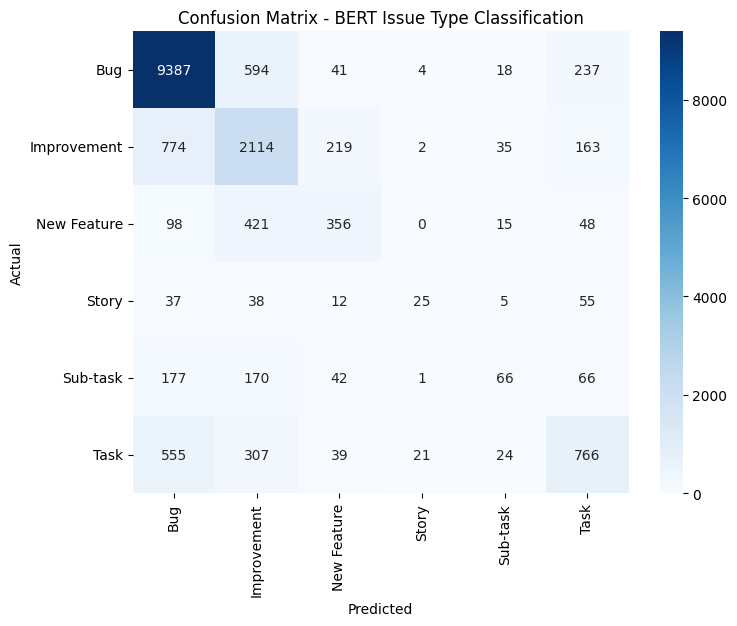

In [25]:
cm = confusion_matrix(y_test_enc, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)

plt.title("Confusion Matrix - BERT Issue Type Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Saving model + Tokenizer + Encoder

In [26]:
trainer.save_model("final_bert_issue_type_model")
tokenizer.save_pretrained("final_bert_issue_type_model")

import joblib
joblib.dump(label_encoder, "issue_type_label_encoder.pkl")

print("Saved BERT model + tokenizer + label encoder")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.38it/s]

Saved BERT model + tokenizer + label encoder


## Priority Prediction Model (Random Forest)

### Feature Engineering for Priority

In [27]:
df["summary_len"] = df["summary"].astype(str).apply(len)
df["desc_len"] = df["description"].astype(str).apply(len)

df["commentcount"] = pd.to_numeric(df["commentcount"], errors="coerce").fillna(0)
df["attachmentcount"] = pd.to_numeric(df["attachmentcount"], errors="coerce").fillna(0)
df["votes"] = pd.to_numeric(df["votes"], errors="coerce").fillna(0)
df["watch_count"] = pd.to_numeric(df["watch_count"], errors="coerce").fillna(0)

df["created"] = pd.to_datetime(df["created"], errors="coerce")
df["updated"] = pd.to_datetime(df["updated"], errors="coerce")

df["age_days"] = (df["updated"] - df["created"]).dt.days
df["age_days"] = df["age_days"].fillna(0)

df.head()

,issue_key,summary,description,issue_type,priority,status,created,updated,projectname,commentcount,attachmentcount,votes,watch_count,labels,total_time_spent_seconds,text,clean_text,summary_len,desc_len,age_days
0,AAR-6171,The Subject matter Of Biorhythms Set,!https://upload.wikimedia.org/wikipedia/common...,Bug,Major,Open,2021-07-23 14:25:25,2021-07-23 14:25:25,AAR,0.0,0.0,0,1,NaN,0.0,The Subject matter Of Biorhythms Set !https://...,the subject matter of biorhythms set it doesn...,36,2865,0
1,AAR-6170,Buy Oxycontin No Prescription Needed | Buy Oxy...,h2. *What is Oxycontin?*\r\n\r\n[Oxycontin |ht...,New Feature,Major,Open,2021-07-23 10:53:39,2021-07-23 10:53:39,AAR,0.0,1.0,0,1,buyoxycontin,0.0,Buy Oxycontin No Prescription Needed | Buy Oxy...,buy oxycontin no prescription needed buy oxyc...,62,7895,0
2,AAR-6169,Natural Remedies For Poor Erection,!https://www.dropshipherbalsupplements.com/wp-...,Bug,Major,Open,2021-07-23 10:28:27,2021-07-23 10:28:27,AAR,0.0,0.0,0,1,NaN,0.0,Natural Remedies For Poor Erection !https://ww...,natural remedies for poor erection with the s...,34,3155,0
3,AAR-6168,download joker,h1. [JOKER GAMING|http://download-jokergaming....,Bug,Major,Open,2021-07-23 09:56:45,2021-07-23 09:56:45,AAR,0.0,0.0,0,1,NaN,0.0,download joker h1. [JOKER GAMING|http://downlo...,download joker h1 joker gaming bermain judi sl...,14,7851,0
4,AAR-6167,BONANZA88 Slot Online Terbaik Indonesia,Kami adalah [slot online|https://172.104.61.28...,Bug,Major,Open,2021-07-23 08:05:06,2021-07-23 08:05:06,AAR,0.0,0.0,0,1,NaN,0.0,BONANZA88 Slot Online Terbaik Indonesia Kami a...,bonanza88 slot online terbaik indonesia kami a...,39,282,0


In [28]:
df.shape

(84657, 20)

### Prepare data for Priority

In [29]:
features = ["summary_len", "desc_len", "commentcount", "attachmentcount", "votes", "watch_count", "age_days"]

X = df[features]
y = df["priority"]

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Training Random Forest

In [30]:
rf_model = RandomForestClassifier(n_estimators=400, random_state=42)
rf_model.fit(X_train_p, y_train_p)

y_pred_rf = rf_model.predict(X_test_p)

print("Random Forest Accuracy:", accuracy_score(y_test_p, y_pred_rf))
print(classification_report(y_test_p, y_pred_rf))

Random Forest Accuracy: 0.6716867469879518
              precision    recall  f1-score   support

     Blocker       0.05      0.01      0.02       721
    Critical       0.27      0.10      0.14      1502
       Major       0.71      0.93      0.81     11950
       Minor       0.22      0.06      0.09      2351
     Trivial       0.06      0.01      0.02       408

    accuracy                           0.67     16932
   macro avg       0.26      0.22      0.21     16932
weighted avg       0.56      0.67      0.59     16932



## Using XGBoost

In [31]:
pip install xgboost

     -------------------------------------- 101.7/101.7 MB 1.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Imports

In [32]:
from xgboost import XGBClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

### Feature Engineering

In [33]:
df["summary_len"] = df["summary"].astype(str).apply(len)
df["desc_len"] = df["description"].astype(str).apply(len)

df["commentcount"] = pd.to_numeric(df["commentcount"], errors="coerce").fillna(0)
df["attachmentcount"] = pd.to_numeric(df["attachmentcount"], errors="coerce").fillna(0)
df["votes"] = pd.to_numeric(df["votes"], errors="coerce").fillna(0)
df["watch_count"] = pd.to_numeric(df["watch_count"], errors="coerce").fillna(0)

df["created"] = pd.to_datetime(df["created"], errors="coerce")
df["updated"] = pd.to_datetime(df["updated"], errors="coerce")

df["age_days"] = (df["updated"] - df["created"]).dt.days
df["age_days"] = df["age_days"].fillna(0)

df.head()

,issue_key,summary,description,issue_type,priority,status,created,updated,projectname,commentcount,attachmentcount,votes,watch_count,labels,total_time_spent_seconds,text,clean_text,summary_len,desc_len,age_days
0,AAR-6171,The Subject matter Of Biorhythms Set,!https://upload.wikimedia.org/wikipedia/common...,Bug,Major,Open,2021-07-23 14:25:25,2021-07-23 14:25:25,AAR,0.0,0.0,0,1,NaN,0.0,The Subject matter Of Biorhythms Set !https://...,the subject matter of biorhythms set it doesn...,36,2865,0
1,AAR-6170,Buy Oxycontin No Prescription Needed | Buy Oxy...,h2. *What is Oxycontin?*\r\n\r\n[Oxycontin |ht...,New Feature,Major,Open,2021-07-23 10:53:39,2021-07-23 10:53:39,AAR,0.0,1.0,0,1,buyoxycontin,0.0,Buy Oxycontin No Prescription Needed | Buy Oxy...,buy oxycontin no prescription needed buy oxyc...,62,7895,0
2,AAR-6169,Natural Remedies For Poor Erection,!https://www.dropshipherbalsupplements.com/wp-...,Bug,Major,Open,2021-07-23 10:28:27,2021-07-23 10:28:27,AAR,0.0,0.0,0,1,NaN,0.0,Natural Remedies For Poor Erection !https://ww...,natural remedies for poor erection with the s...,34,3155,0
3,AAR-6168,download joker,h1. [JOKER GAMING|http://download-jokergaming....,Bug,Major,Open,2021-07-23 09:56:45,2021-07-23 09:56:45,AAR,0.0,0.0,0,1,NaN,0.0,download joker h1. [JOKER GAMING|http://downlo...,download joker h1 joker gaming bermain judi sl...,14,7851,0
4,AAR-6167,BONANZA88 Slot Online Terbaik Indonesia,Kami adalah [slot online|https://172.104.61.28...,Bug,Major,Open,2021-07-23 08:05:06,2021-07-23 08:05:06,AAR,0.0,0.0,0,1,NaN,0.0,BONANZA88 Slot Online Terbaik Indonesia Kami a...,bonanza88 slot online terbaik indonesia kami a...,39,282,0


### Load BERT Model for Issue Type Prediction

In [36]:
import torch
import joblib
from transformers import AutoTokenizer, AutoModelForSequenceClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained("final_bert_issue_type_model")
bert_model = AutoModelForSequenceClassification.from_pretrained("final_bert_issue_type_model")

bert_model.to(device)
bert_model.eval()

label_encoder = joblib.load("issue_type_label_encoder.pkl")

print("BERT model loaded on:", device)

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 8410.60it/s]


BERT model loaded on: cuda


### Batch Prediction Function for BERT Issue Type

In [39]:
import torch
import numpy as np

def batch_predict_issue_type(text_list, batch_size=64, max_len=128):

    predictions = []

    for i in range(0, len(text_list), batch_size):
        batch_texts = text_list[i:i+batch_size]

        inputs = tokenizer(
            batch_texts,
            truncation=True,
            padding=True,
            max_length=max_len,
            return_tensors="pt"
        )

        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = bert_model(**inputs)

        batch_preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        predictions.extend(batch_preds)

        if i % (batch_size * 50) == 0:
            print(f"Processed {i}/{len(text_list)} texts...")

    predicted_labels = label_encoder.inverse_transform(predictions)
    return predicted_labels

### Generate BERT Predicted Issue Type Feature

In [40]:
texts = df["clean_text"].tolist()

df["bert_predicted_issue_type"] = batch_predict_issue_type(texts, batch_size=64)

df[["issue_type", "bert_predicted_issue_type"]].head(10)

Processed 0/84657 texts...
Processed 3200/84657 texts...
Processed 6400/84657 texts...
Processed 9600/84657 texts...
Processed 12800/84657 texts...
Processed 16000/84657 texts...
Processed 19200/84657 texts...
Processed 22400/84657 texts...
Processed 25600/84657 texts...
Processed 28800/84657 texts...
Processed 32000/84657 texts...
Processed 35200/84657 texts...
Processed 38400/84657 texts...
Processed 41600/84657 texts...
Processed 44800/84657 texts...
Processed 48000/84657 texts...
Processed 51200/84657 texts...
Processed 54400/84657 texts...
Processed 57600/84657 texts...
Processed 60800/84657 texts...
Processed 64000/84657 texts...
Processed 67200/84657 texts...
Processed 70400/84657 texts...
Processed 73600/84657 texts...
Processed 76800/84657 texts...
Processed 80000/84657 texts...
Processed 83200/84657 texts...


,issue_type,bert_predicted_issue_type
0,Bug,Bug
1,New Feature,Bug
2,Bug,Bug
3,Bug,Bug
4,Bug,Bug
5,Bug,Bug
6,Bug,Bug
7,Bug,Bug
8,Bug,Bug
9,Bug,Bug


### Prepare Dataset for XGBoost (Train-Test Split)

In [41]:
numeric_features = [
    "summary_len", "desc_len",
    "commentcount", "attachmentcount",
    "votes", "watch_count",
    "age_days"
]

categorical_features = ["bert_predicted_issue_type"]

X = df[numeric_features + categorical_features]
y = df["priority"]

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train_p.shape)
print("Test Shape:", X_test_p.shape)

Train Shape: (67725, 8)
Test Shape: (16932, 8)


### Preprocessing: OneHotEncoding Categorical Feature

In [42]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

### Initialize XGBoost Classifier

In [43]:
xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42
)

### Encode Priority Labels (Label Encoding)

In [45]:
from sklearn.preprocessing import LabelEncoder

priority_encoder = LabelEncoder()

y_train_enc = priority_encoder.fit_transform(y_train_p)
y_test_enc = priority_encoder.transform(y_test_p)

print("Priority Classes:", priority_encoder.classes_)

Priority Classes: ['Blocker' 'Critical' 'Major' 'Minor' 'Trivial']


### Build Pipeline and Train XGBoost Model

In [46]:
priority_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", xgb_model)
])

priority_pipeline.fit(X_train_p, y_train_enc)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

### Evaluate XGBoost Model Performance

In [47]:
y_pred_xgb = priority_pipeline.predict(X_test_p)

# Convert back to original labels
y_pred_labels = priority_encoder.inverse_transform(y_pred_xgb)
y_test_labels = priority_encoder.inverse_transform(y_test_enc)

print("XGBoost Accuracy:", accuracy_score(y_test_labels, y_pred_labels))
print(classification_report(y_test_labels, y_pred_labels))

XGBoost Accuracy: 0.7056461138672336
              precision    recall  f1-score   support

     Blocker       0.50      0.00      0.01       721
    Critical       0.39      0.03      0.05      1502
       Major       0.71      0.99      0.83     11950
       Minor       0.52      0.02      0.04      2351
     Trivial       0.33      0.00      0.01       408

    accuracy                           0.71     16932
   macro avg       0.49      0.21      0.19     16932
weighted avg       0.64      0.71      0.59     16932



### Save Trained XGBoost Pipeline

In [48]:
import joblib

joblib.dump(priority_pipeline, "priority_xgboost_pipeline.pkl")
print("Saved priority model pipeline as priority_xgboost_pipeline.pkl")

Saved priority model pipeline as priority_xgboost_pipeline.pkl


### Saving Encoder

In [55]:
import joblib
joblib.dump(priority_encoder, "priority_label_encoder.pkl")

['priority_label_encoder.pkl']

### Load Saved XGBoost Pipeline

In [49]:
priority_pipeline = joblib.load("priority_xgboost_pipeline.pkl")

### Priority Prediction Function for New Tasks

In [53]:
def predict_priority(new_task_text):

    summary_len = len(new_task_text)
    desc_len = len(new_task_text)

    predicted_issue_type = predict_issue_type_bert(new_task_text)

    sample = pd.DataFrame([{
        "summary_len": summary_len,
        "desc_len": desc_len,
        "commentcount": 0,
        "attachmentcount": 0,
        "votes": 0,
        "watch_count": 0,
        "age_days": 0,
        "bert_predicted_issue_type": predicted_issue_type
    }])

    pred_encoded = priority_pipeline.predict(sample)[0]

    # decode back to original priority label
    pred_label = priority_encoder.inverse_transform([pred_encoded])[0]

    return pred_label

### Testing the Priority Prediction Model

In [54]:
new_task = "Urgent crash issue in android plugin while uploading images."

print("Predicted Issue Type:", predict_issue_type_bert(new_task))
print("Predicted Priority:", predict_priority(new_task))

Predicted Issue Type: Bug
Predicted Priority: Major


## Workload Balancing using Users Dataset

### Loading Users Workload Dataset

In [63]:
users_df = pd.read_csv(r"D:\Project Infy\jira_users_with_workload.csv")

users_df["active"] = users_df["active"].fillna(False)
users_df["total_user_workload_seconds"] = users_df["total_user_workload_seconds"].fillna(0)

print("Users Dataset Shape:", users_df.shape)
users_df.head()

Users Dataset Shape: (31, 5)


,user,total_user_workload_seconds,display_name,email,active
0,githubbot,56980200,ASF GitHub Bot,Unknown,True
1,tobias.istvan,4342320,Istvan Tobias,Unknown,True
2,jira-bot,2236200,ASF subversion and git services,Unknown,True
3,lpuskas,1468800,Laszlo Puskas,Unknown,True
4,ashutoshm,518400,Ashutosh Mehra,Unknown,False


In [64]:
users_df

,user,total_user_workload_seconds,display_name,email,active
0,githubbot,56980200,ASF GitHub Bot,Unknown,True
1,tobias.istvan,4342320,Istvan Tobias,Unknown,True
2,jira-bot,2236200,ASF subversion and git services,Unknown,True
3,lpuskas,1468800,Laszlo Puskas,Unknown,True
4,ashutoshm,518400,Ashutosh Mehra,Unknown,False
5,semog,463860,Semog G,Unknown,False
6,tabish121,447000,Tabish J,Unknown,False
7,jgomes,388200,Jim Gomes,Unknown,True
8,jluniya,378000,Jayush Luniya,Unknown,True
9,nickpoorman,365280,Nick Poorman,Unknown,True


### Workload Balancing Function

In [65]:
def suggest_assignee_and_update(users_df):

    # Only choose active users
    active_users = users_df[users_df["active"] == True]

    if active_users.empty:
        print("⚠️ No active users left. Resetting all users to active.")
        users_df["active"] = True
        active_users = users_df[users_df["active"] == True]

    # Select least loaded user
    least_loaded_idx = active_users["total_user_workload_seconds"].idxmin()

    selected_user = users_df.loc[least_loaded_idx]

    # Mark user inactive after assignment
    users_df.loc[least_loaded_idx, "active"] = False

    return selected_user["user"], selected_user["display_name"]

## Final Integrated System (End-to-End)

### Loading model for prediction

In [66]:
import torch
import joblib
from transformers import AutoTokenizer, AutoModelForSequenceClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained("final_bert_issue_type_model")
bert_model = AutoModelForSequenceClassification.from_pretrained("final_bert_issue_type_model")

bert_model.to(device)
bert_model.eval()

label_encoder = joblib.load("issue_type_label_encoder.pkl")

print("Device:", device)

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 11557.62it/s]


Device: cuda


### Predicting Issue Type Function

In [67]:
def predict_issue_type_bert(text):

    cleaned = clean_text(text)

    inputs = tokenizer(cleaned, return_tensors="pt", truncation=True, padding=True, max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = bert_model(**inputs)

    pred_class = torch.argmax(outputs.logits, dim=1).item()
    return label_encoder.inverse_transform([pred_class])[0]

### Final Prediction Function

In [68]:
def predict_task(new_task_text, users_df):

    predicted_type = predict_issue_type_bert(new_task_text)

    summary_len = len(new_task_text)
    desc_len = len(new_task_text)

    sample = pd.DataFrame([{
        "summary_len": summary_len,
        "desc_len": desc_len,
        "commentcount": 0,
        "attachmentcount": 0,
        "votes": 0,
        "watch_count": 0,
        "age_days": 0,
        "bert_predicted_issue_type": predicted_type
    }])

    pred_encoded = priority_pipeline.predict(sample)[0]
    predicted_priority = priority_encoder.inverse_transform([pred_encoded])[0]

    user_id, display_name = suggest_assignee_and_update(users_df)

    return predicted_type, predicted_priority, user_id, display_name

### Testing the System

In [69]:
tasks = [
    "System crash occurs when uploading file. Needs urgent fix.",
    "UI button not working in dashboard page. Needs improvement.",
    "Add new login feature for admin panel."
]

for task in tasks:
    pred_type, pred_priority, pred_user, pred_display = predict_task(task, users_df)

    print("\nNew Task:", task)
    print("Predicted Issue Type:", pred_type)
    print("Predicted Priority:", pred_priority)
    print("Suggested Assignee UserID:", pred_user)
    print("Suggested Assignee Name:", pred_display)


New Task: System crash occurs when uploading file. Needs urgent fix.
Predicted Issue Type: Bug
Predicted Priority: Major
Suggested Assignee UserID: elserj
Suggested Assignee Name: Josh Elser

New Task: UI button not working in dashboard page. Needs improvement.
Predicted Issue Type: Bug
Predicted Priority: Major
Suggested Assignee UserID: ctubbsii
Suggested Assignee Name: Christopher Tubbs

New Task: Add new login feature for admin panel.
Predicted Issue Type: Task
Predicted Priority: Major
Suggested Assignee UserID: qwertymaniac
Suggested Assignee Name: Harsh J
